In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/cars_clean.csv")

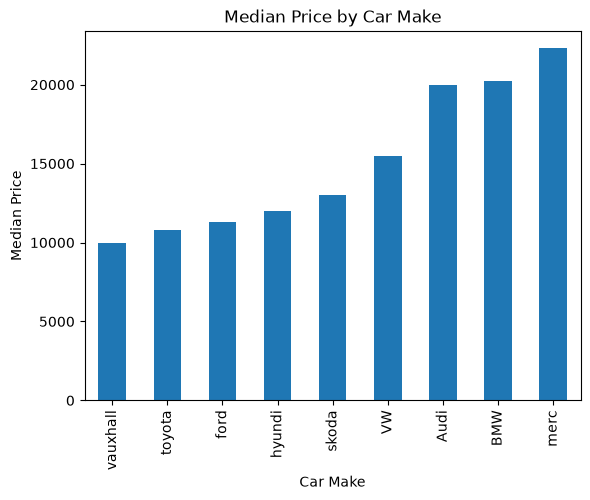

In [3]:
df.groupby("Make")["price"].median().sort_values().plot(kind="bar")

plt.xlabel("Car Make")
plt.ylabel("Median Price")
plt.title("Median Price by Car Make")
plt.show()

### Price by Car Make

The median price varies across car makes.
Some brands have noticeably higher typical used-car prices,
while others are positioned in lower price ranges.
This suggests that car make is an important factor in used-car pricing.

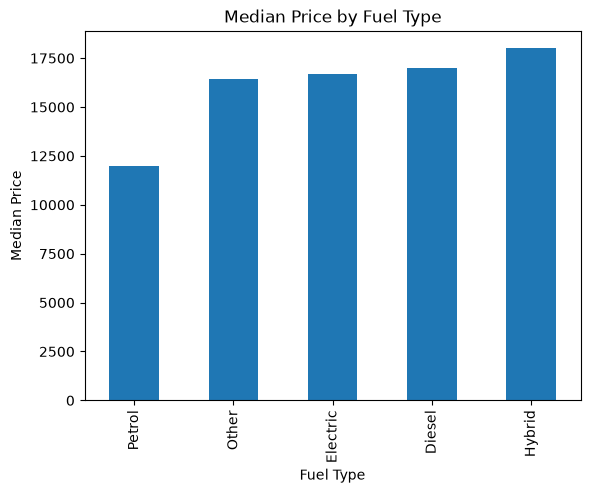

In [4]:
df.groupby("fuelType")["price"].median().sort_values().plot(kind="bar")

plt.xlabel("Fuel Type")
plt.ylabel("Median Price")
plt.title("Median Price by Fuel Type")
plt.show()

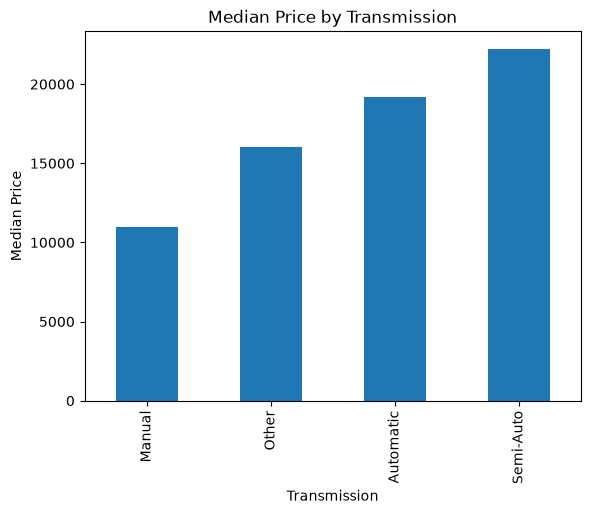

In [5]:
df.groupby("transmission")["price"].median().sort_values().plot(kind="bar")

plt.xlabel("Transmission")
plt.ylabel("Median Price")
plt.title("Median Price by Transmission")
plt.show()

In [6]:
df["Make"].value_counts().head(15)

Make
ford        17810
VW          14892
vauxhall    13257
merc        12855
BMW         10650
Audi        10565
toyota       6688
skoda        6188
hyundi       4770
Name: count, dtype: int64

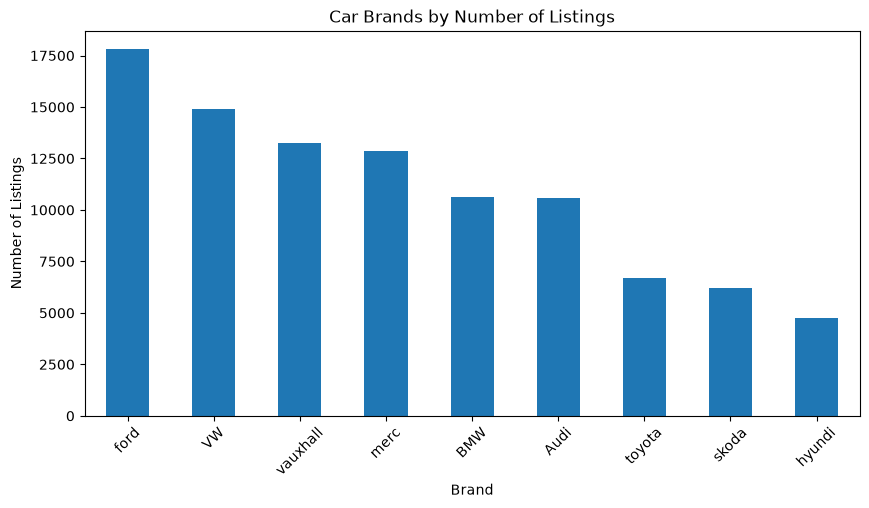

In [7]:
df["Make"].value_counts().head(15).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Car Brands by Number of Listings")
plt.xlabel("Brand")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)

plt.show()

### Insight

The used-car dataset is concentrated around a small number of brands. Ford has the highest number of listings, followed by Volkswagen, Vauxhall, and Mercedes. This indicates that these brands have the strongest representation in the dataset and should receive greater attention in later market and recommendation analysis.

In [8]:
df["model"].value_counts().head(15)

model
Fiesta      6508
Golf        4797
Focus       4555
C Class     3694
Corsa       3285
Polo        3244
Astra       2655
A Class     2471
3 Series    2426
Kuga        2208
Yaris       2117
Mokka X     2111
1 Series    1962
Aygo        1940
E Class     1928
Name: count, dtype: int64

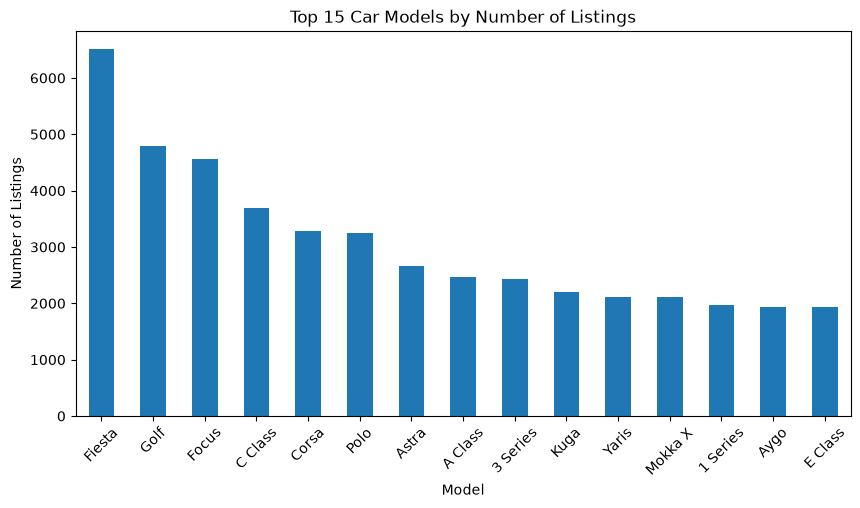

In [9]:
df["model"].value_counts().head(15).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 15 Car Models by Number of Listings")
plt.xlabel("Model")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)

plt.show()

### Insight

The dataset is concentrated among a relatively small number of models. The Ford Fiesta has the highest number of listings, followed by the Volkswagen Golf and Ford Focus. This shows that these models have strong representation in the dataset and provides a useful basis for deeper model-level price and value analysis.

In [10]:
df.groupby(["Make", "model"]).size().sort_values(ascending=False).head(20)

Make      model   
ford      Fiesta      6508
VW        Golf        4797
ford      Focus       4555
merc      C Class     3694
vauxhall  Corsa       3285
VW        Polo        3244
vauxhall  Astra       2655
merc      A Class     2471
BMW       3 Series    2426
ford      Kuga        2208
toyota    Yaris       2117
vauxhall  Mokka X     2111
BMW       1 Series    1962
toyota    Aygo        1940
merc      E Class     1928
Audi      A3          1917
VW        Tiguan      1743
skoda     Fabia       1544
          Octavia     1466
Audi      Q3          1379
dtype: int64

### Insight

The market is concentrated around a small number of brand–model combinations. The Ford Fiesta has the highest representation with 6,557 listings, followed by the Volkswagen Golf and Ford Focus. This suggests that model-level analysis will be important for understanding used-car market patterns and building the future recommendation system.

In [11]:
popular_models = df["model"].value_counts().head(15).index

df[df["model"].isin(popular_models)].groupby("model")["price"].median().sort_values()

model
Aygo         7880.0
Corsa        7995.0
Fiesta       9995.0
Astra       10000.0
Yaris       10645.0
Polo        10700.0
Mokka X     12400.0
Focus       12750.0
1 Series    14799.5
Kuga        15972.5
Golf        15998.0
A Class     17990.0
3 Series    18195.0
E Class     22980.0
C Class     22993.0
Name: price, dtype: float64

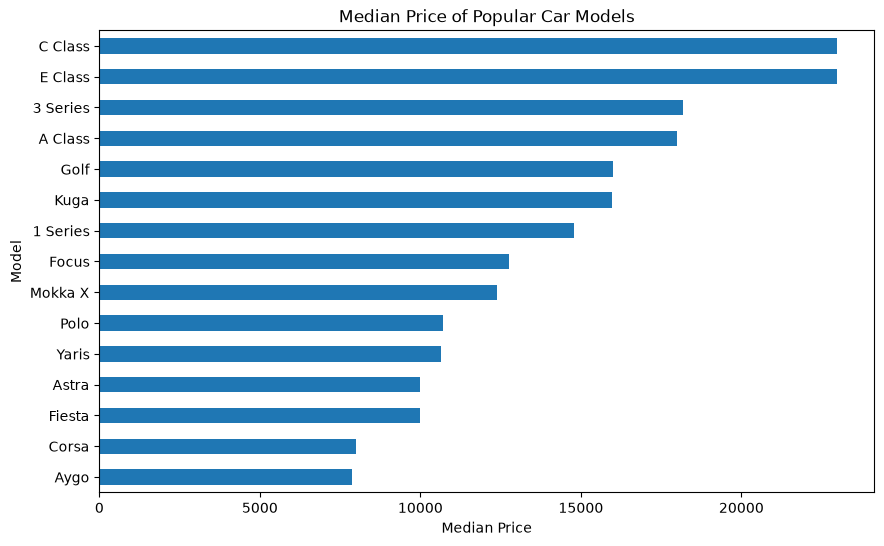

In [12]:
model_prices = (
    df[df["model"].isin(popular_models)]
    .groupby("model")["price"]
    .median()
    .sort_values()
)

model_prices.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Median Price of Popular Car Models")
plt.xlabel("Median Price")
plt.ylabel("Model")

plt.show()

### Insight

Popular models show substantial differences in median used-car prices. The Aygo and Corsa occupy the lower-priced end of the market, while the Mercedes C Class and E Class are positioned at the higher end. This variation indicates that model choice is an important factor in determining the budget required for a used car.

In [13]:
df["price_segment"] = pd.cut(
    df["price"],
    bins=[0, 10000, 15000, 20000, float("inf")],
    labels=["Budget", "Mid-Range", "Premium", "Luxury"]
)

df["price_segment"].value_counts()

price_segment
Mid-Range    27524
Luxury       25705
Budget       24961
Premium      19485
Name: count, dtype: int64

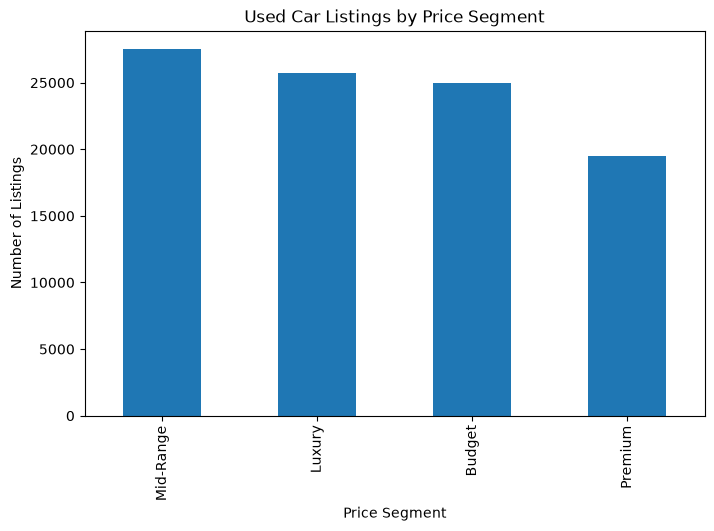

In [14]:
df["price_segment"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Used Car Listings by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Number of Listings")

plt.show()

### Insight

The used-car market can be divided into four price segments: Budget, Mid-Range, Premium, and Luxury. The distribution shows where most listings are concentrated and provides a foundation for budget-based car recommendations.

In [15]:
df.columns.tolist()

['model',
 'year',
 'price',
 'transmission',
 'mileage',
 'fuelType',
 'tax',
 'mpg',
 'engineSize',
 'Make',
 'age',
 'price_log',
 'price_segment']

In [16]:
brand_price = df.groupby("Make")["price"].median().sort_values(ascending=False)

brand_price

Make
merc        22299.0
BMW         20219.5
Audi        20000.0
VW          15493.0
skoda       12998.0
hyundi      11990.0
ford        11289.5
toyota      10795.0
vauxhall     9998.0
Name: price, dtype: float64

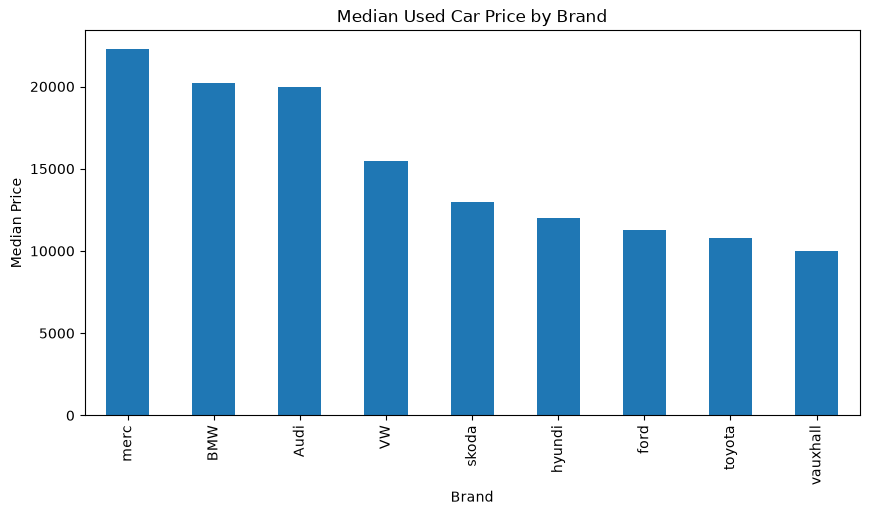

In [17]:
brand_price.plot(kind="bar", figsize=(10, 5))

plt.title("Median Used Car Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Median Price")

plt.show()

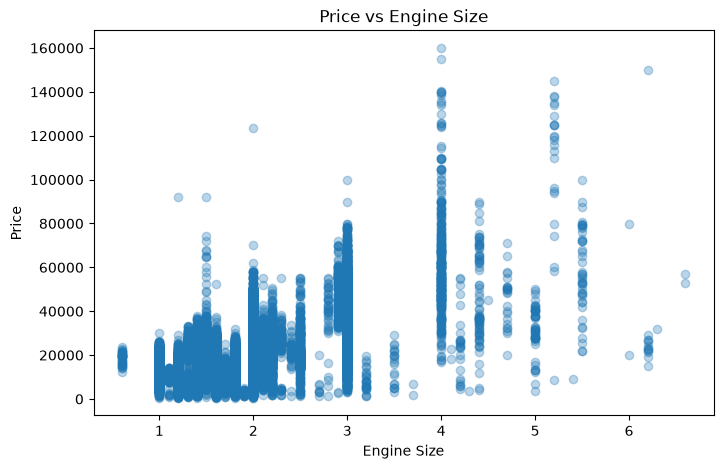

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(df["engineSize"], df["price"], alpha=0.3)

plt.title("Price vs Engine Size")
plt.xlabel("Engine Size")
plt.ylabel("Price")

plt.show()

In [19]:
fuel_segment = pd.crosstab(df["fuelType"], df["price_segment"])

fuel_segment

price_segment,Budget,Mid-Range,Premium,Luxury
fuelType,,,,
Diesel,5933,9915,10277,14282
Electric,0,1,5,0
Hybrid,139,902,842,1155
Other,56,52,65,73
Petrol,18833,16654,8296,10195


In [20]:
transmission_segment = pd.crosstab(
    df["transmission"],
    df["price_segment"]
)

transmission_segment

price_segment,Budget,Mid-Range,Premium,Luxury
transmission,,,,
Automatic,1685,4290,4990,8924
Manual,22522,20019,9526,3429
Other,0,4,4,1
Semi-Auto,754,3211,4965,13351


In [21]:
brand_segment = pd.crosstab(
    df["Make"],
    df["price_segment"]
)

brand_segment

price_segment,Budget,Mid-Range,Premium,Luxury
Make,,,,
Audi,606,2048,2648,5263
BMW,699,2161,2449,5341
VW,2966,4291,3453,4182
ford,6661,6599,3734,816
hyundi,1962,1431,922,455
merc,362,1559,3286,7648
skoda,1852,2120,1180,1036
toyota,3002,2058,778,850
vauxhall,6851,5257,1035,114
